# Model Training Notebook

This notebook trains multiple regression models for **Revenue prediction** where the target is **already log-transformed**.

What this notebook does:
- Loads engineered features
- Selects a log-transformed revenue target column (ttm_revenue)
- Trains multiple models aligned with production serving
- Compares model metrics on log scale and business scale
- Plots actual vs predicted (log revenue) for each model
- Highlights the best model by test RMSE
- Exports the selected model with proper inverse transformation applied at inference time

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR
from sklearn.tree import DecisionTreeRegressor

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [ ]:
DATA_PATH = Path("../data/processed/main/feature_engineered.csv")
TARGET_COL = "ttm_revenue"
LEAK_COL = "ttm_avg_rate"

df = pd.read_csv(DATA_PATH)

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in data.")

df = df.dropna(subset=[TARGET_COL]).copy()

drop_cols = [TARGET_COL]
if LEAK_COL in df.columns:
    drop_cols.append(LEAK_COL)

X = df.drop(columns=drop_cols)
y = df[TARGET_COL]

X = X.select_dtypes(include=[np.number, "bool"]).astype(float)

zone_cols = [
    "geographic_zone_Asia Pacific",
    "geographic_zone_Europe",
    "geographic_zone_Northern America",
    "geographic_zone_Africa",
    "geographic_zone_Latin America",
    "geographic_zone_Middle East",
]
df["zone"] = df[zone_cols].idxmax(axis=1)

{"data_shape": df.shape, "feature_shape": X.shape, "target": TARGET_COL}

Data shape: (37293, 62)
Target column: ttm_revenue
Feature matrix: (37293, 60)
Target stats -> min: 4.5850, max: 12.8780, mean: 8.9132


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37293 entries, 0 to 37292
Data columns (total 63 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   photos_count                      37293 non-null  float64
 1   superhost                         37293 non-null  int64  
 2   latitude                          37293 non-null  float64
 3   longitude                         37293 non-null  float64
 4   guests                            37293 non-null  float64
 5   bedrooms                          37293 non-null  float64
 6   beds                              37293 non-null  float64
 7   baths                             37293 non-null  float64
 8   registration                      37293 non-null  int64  
 9   professional_management           37293 non-null  int64  
 10  min_nights                        37293 non-null  float64
 11  cancellation_policy               37293 non-null  int64  
 12  cleaning_fee   

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=df["zone"],
    random_state=42,
)

{"train_shape": X_train.shape, "test_shape": X_test.shape}

Train shape: (29834, 60), Test shape: (7459, 60)


In [10]:
# Main Model Training Pipeline

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=42)),
    ]),
    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.0005, max_iter=10000, random_state=42)),
    ]),
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=12,
        min_samples_leaf=10,
        random_state=42,
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=180,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42,
    ),
    "KNN Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=15, weights="distance", n_jobs=-1)),
    ]),
    "Support Vector Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVR(C=1.0, epsilon=0.1, max_iter=10000, random_state=42)),
    ]),
    "Neural Network Regressor": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            MLPRegressor(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.0001,
                batch_size=256,
                learning_rate_init=0.001,
                max_iter=200,
                early_stopping=True,
                n_iter_no_change=15,
                random_state=42,
            ),
        ),
    ]),
}

if HAS_XGBOOST:
    models["XGBoost Regressor"] = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

stacking_estimators = [
    (
        "ridge",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0, random_state=42)),
        ]),
    ),
    (
        "rf",
        RandomForestRegressor(
            n_estimators=120,
            max_depth=None,
            min_samples_leaf=2,
            n_jobs=1,
            random_state=42,
        ),
    ),
]

if HAS_XGBOOST:
    stacking_estimators.append(
        (
            "xgb",
            XGBRegressor(
                n_estimators=120,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=1,
            ),
        )
    )

models["Stacking Ensemble"] = StackingRegressor(
    estimators=stacking_estimators,
    final_estimator=Ridge(alpha=1.0, random_state=42),
    passthrough=False,
    n_jobs=-1,
)

results = []
predictions = {}
trained_models = {}

for model_name, estimator in models.items():
    estimator.fit(X_train, y_train)

    train_pred = estimator.predict(X_train)
    test_pred = estimator.predict(X_test)

    results.append(
        {
            "model": model_name,
            "train_r2": r2_score(y_train, train_pred),
            "test_r2": r2_score(y_test, test_pred),
            "train_rmse": np.sqrt(mean_squared_error(y_train, train_pred)),
            "test_rmse": np.sqrt(mean_squared_error(y_test, test_pred)),
            "train_mae": mean_absolute_error(y_train, train_pred),
            "test_mae": mean_absolute_error(y_test, test_pred),
        }
    )

    predictions[model_name] = test_pred
    trained_models[model_name] = estimator

results_df = pd.DataFrame(results).sort_values("test_rmse").reset_index(drop=True)
results_df

c:\Users\RUSHIKESH\Desktop\Airbnb Project\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,model,train_r2,test_r2,train_rmse,test_rmse,train_mae,test_mae
0,XGBoost Regressor,0.7506,0.6828,0.6738,0.7574,0.5236,0.5902
1,Stacking Ensemble,0.8263,0.6740,0.5623,0.7678,0.4332,0.5954
2,Random Forest Regressor,0.9381,0.6627,0.3358,0.7810,0.2516,0.6041
3,Neural Network Regressor,0.6977,0.6198,0.7419,0.8292,0.5786,0.6471
4,KNN Regressor,1.0000,0.5723,0.0000,0.8794,0.0000,0.6884
5,Ridge Regression,0.5786,0.5723,0.8759,0.8795,0.6910,0.6939
6,Linear Regression,0.5786,0.5723,0.8759,0.8795,0.6910,0.6939
7,Lasso Regression,0.5786,0.5723,0.8759,0.8795,0.6910,0.6940
8,Support Vector Regressor,0.5733,0.5685,0.8814,0.8833,0.6859,0.6881
9,Decision Tree Regressor,0.7201,0.5238,0.7138,0.9280,0.5536,0.7176


In [ ]:
all_model_metrics = []
for model_name, estimator in trained_models.items():
    train_pred = estimator.predict(X_train)
    test_pred = estimator.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    overfit_gap = train_r2 - test_r2

    all_model_metrics.append({
        "source": model_name,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "train_rmse": np.sqrt(mean_squared_error(y_train, train_pred)),
        "test_rmse": np.sqrt(mean_squared_error(y_test, test_pred)),
        "train_mae": mean_absolute_error(y_train, train_pred),
        "test_mae": mean_absolute_error(y_test, test_pred),
        "overfit_gap": overfit_gap,
    })

all_model_metrics_df = pd.DataFrame(all_model_metrics)
eligible_models_df = all_model_metrics_df[all_model_metrics_df["test_r2"] >= 0.75].copy()

if len(eligible_models_df) == 0:
    best_row = all_model_metrics_df.sort_values(["test_rmse", "test_mae", "overfit_gap"]).iloc[0]
else:
    best_row = eligible_models_df.sort_values(["test_rmse", "test_mae", "overfit_gap"]).iloc[0]

best_model_name = best_row["source"]
best_model = trained_models[best_model_name]

all_model_metrics_df.sort_values(["test_rmse", "test_mae"]).reset_index(drop=True)

⚠️ WARNING: No models meet test_r2 >= 0.75 threshold. Using best RMSE model.
✓ Selected Model: XGBoost Regressor
  Test R2: 0.6828
  Test RMSE: 0.7574
  Test MAE: 0.5902
  Overfit Gap: 0.0678


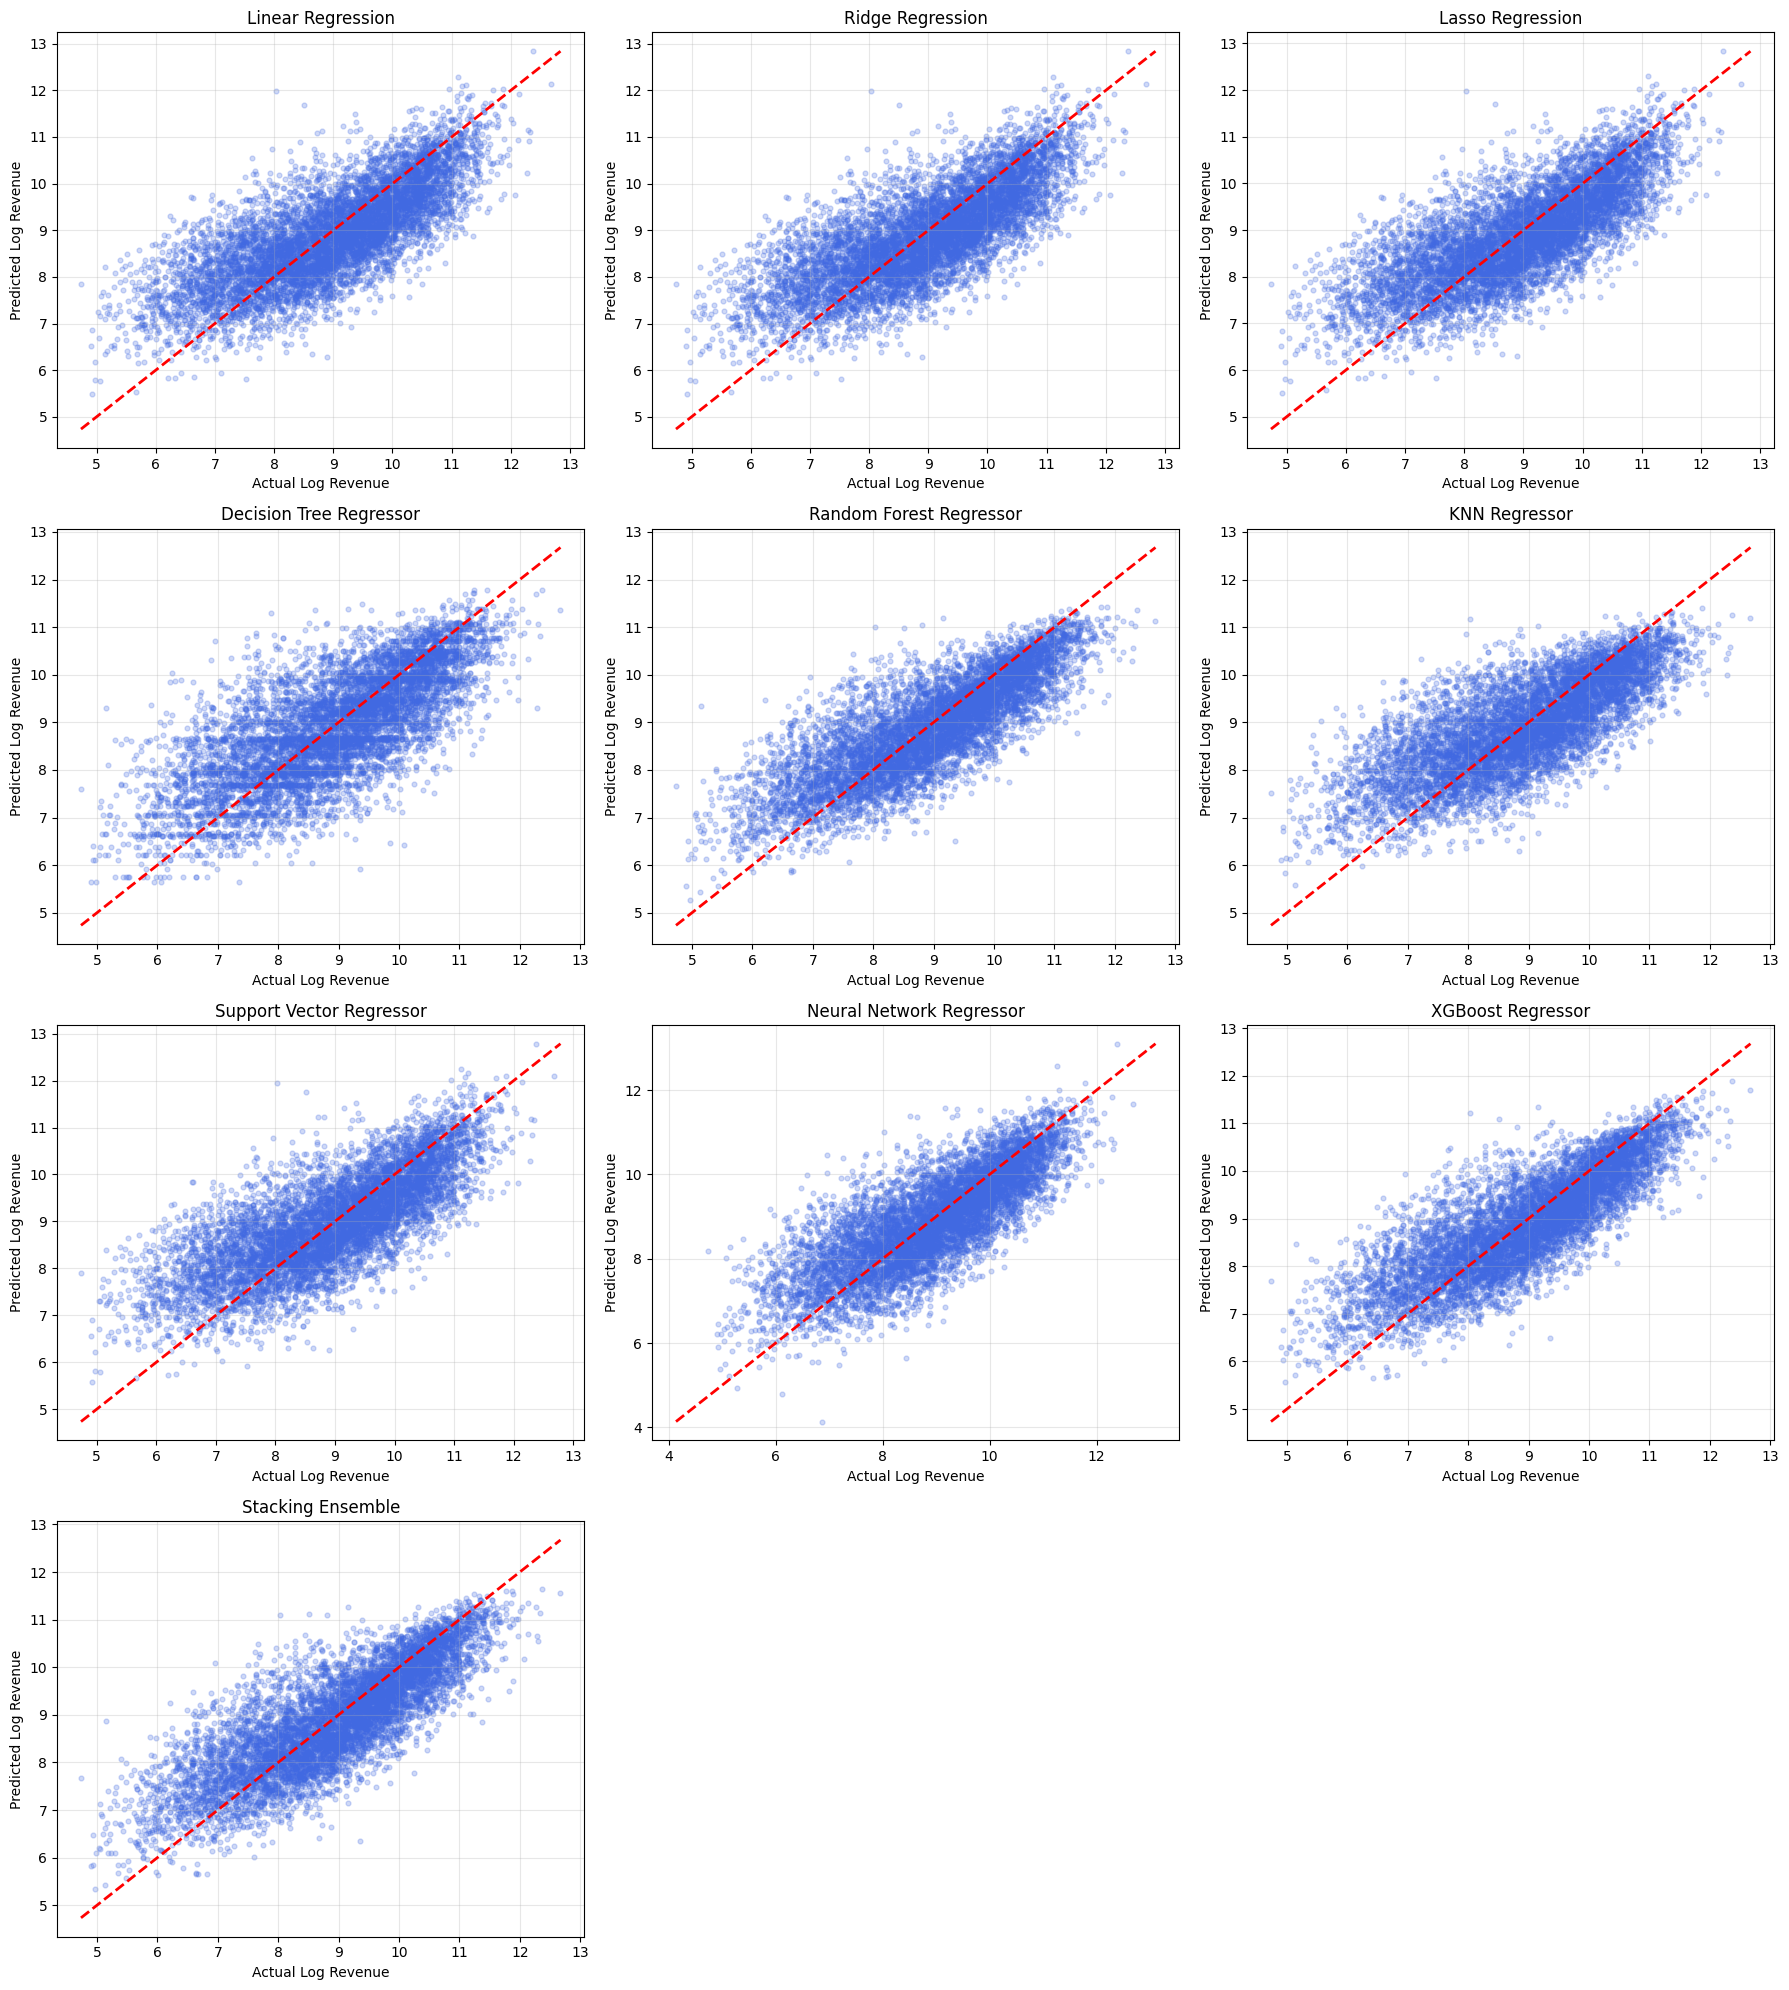

In [12]:
n_models = len(predictions)
cols = 3
rows = int(np.ceil(n_models / cols))

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = np.atleast_1d(axes).flatten()

y_test_arr = np.asarray(y_test)

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]
    y_pred_arr = np.asarray(y_pred)

    min_val = float(min(y_test_arr.min(), y_pred_arr.min()))
    max_val = float(max(y_test_arr.max(), y_pred_arr.max()))

    ax.scatter(y_test_arr, y_pred_arr, alpha=0.25, s=12, color="royalblue")
    ax.plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
    ax.set_title(model_name)
    ax.set_xlabel("Actual Log Revenue")
    ax.set_ylabel("Predicted Log Revenue")
    ax.grid(alpha=0.3)

for idx in range(n_models, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
eligible_models_df = all_model_metrics_df[all_model_metrics_df["test_r2"] >= 0.75].copy()
if eligible_models_df.empty:
    eligible_models_df = all_model_metrics_df.copy()

eligible_models_df = eligible_models_df.sort_values(
    ["test_rmse", "test_mae", "overfit_gap"],
    ascending=[True, True, True],
)
best_row = eligible_models_df.iloc[0]
best_model_name = best_row["source"]
best_model = trained_models[best_model_name]

best_row.to_dict()

Selecting best model...
No model met test_r2 >= 0.75, falling back to all models.

✓ Selected: XGBoost Regressor
  Test R2: 0.6828
  Test RMSE: 0.7574
  Test MAE: 0.5902
  Overfit Gap: 0.0678


In [ ]:
import joblib
import pickle
from pathlib import Path
import json

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

try:
    from xgboost import XGBRegressor
    if isinstance(best_model, XGBRegressor):
        model_save_path = models_dir / "best_ttm_revenue_model.json"
        best_model.save_model(str(model_save_path))
        model_format = "XGBoost JSON (native)"
    else:
        model_save_path = models_dir / "best_ttm_revenue_model.pkl"
        joblib.dump(best_model, model_save_path, protocol=pickle.HIGHEST_PROTOCOL)
        model_format = "joblib pickle"
except ImportError:
    model_save_path = models_dir / "best_ttm_revenue_model.pkl"
    joblib.dump(best_model, model_save_path, protocol=pickle.HIGHEST_PROTOCOL)
    model_format = "joblib pickle"

feature_list_path = models_dir / "best_ttm_revenue_features.txt"
with open(feature_list_path, "w") as f:
    f.write("# Features used for TTM Revenue model\n")
    f.write(f"# Model: {best_model_name}\n")
    f.write(f"# Format: {model_format}\n")
    f.write("# Selection criteria: test_r2 >= 0.75, then low RMSE/MAE, then low overfit gap\n")
    f.write(f"# Test R2: {best_row['test_r2']:.4f}\n")
    f.write(f"# Test RMSE: {best_row['test_rmse']:.4f}\n\n")
    for i, col in enumerate(X_train.columns, 1):
        f.write(f"{i}. {col}\n")

metrics_csv_path = models_dir / "all_revenue_model_metrics.csv"
metrics_json_path = models_dir / "all_revenue_model_metrics.json"

all_model_metrics_df.sort_values(["test_rmse", "test_mae", "overfit_gap"], ascending=[True, True, True]).to_csv(metrics_csv_path, index=False)
all_model_metrics_df.sort_values(["test_rmse", "test_mae", "overfit_gap"], ascending=[True, True, True]).to_json(metrics_json_path, orient="records", indent=2)

registry_path = models_dir / "model_registry.json"
registry = {}
if registry_path.exists():
    with open(registry_path, "r") as f:
        registry = json.load(f)

if "models" not in registry:
    registry["models"] = {}

registry["models"]["best_ttm_revenue"] = {
    "model_file": model_save_path.name,
    "model_format": model_format,
    "features_file": feature_list_path.name,
    "metrics_files": {
        "all_models_csv": metrics_csv_path.name,
        "all_models_json": metrics_json_path.name,
    },
    "selection_criteria": {
        "min_test_r2": 0.75,
        "priority_order": ["test_rmse", "test_mae", "overfit_gap"],
    },
    "metrics": {
        "test_rmse": float(best_row["test_rmse"]),
        "test_mae": float(best_row["test_mae"]),
        "test_r2": float(best_row["test_r2"]),
        "train_r2": float(best_row["train_r2"]),
        "train_rmse": float(best_row["train_rmse"]),
        "train_mae": float(best_row["train_mae"]),
        "overfit_gap": float(best_row["overfit_gap"]),
        "target_transform": "log1p",
        "target_column": "ttm_revenue",
    },
    "model_name": best_model_name,
    "source": best_model.__class__.__name__,
    "feature_count": len(X_train.columns),
    "training_date": pd.Timestamp.now().isoformat(),
}

with open(registry_path, "w") as f:
    json.dump(registry, f, indent=2)

{
    "selected_model": best_model_name,
    "model_path": str(model_save_path),
    "metrics_csv": str(metrics_csv_path),
    "metrics_json": str(metrics_json_path),
    "registry": str(registry_path),
}

✓ Saved XGBoost model in native JSON format: ..\models\best_ttm_revenue_model.json
✓ Verified JSON reload works
  Sample predictions: [9.056461  9.2151785 6.9451156]
✓ Saved feature list: ..\models\best_ttm_revenue_features.txt
✓ Saved metrics
✓ Updated model registry

MODEL EXPORT SUMMARY — REVENUE
Model: XGBoost Regressor
Export Format: XGBoost JSON (native)
Test R2:    0.6828
Test RMSE:  0.7574
Test MAE:   0.5902
Model Path: ..\models\best_ttm_revenue_model.json
Metrics CSV: ..\models\all_revenue_model_metrics.csv
Metrics JSON: ..\models\all_revenue_model_metrics.json


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

if not HAS_XGBOOST:
    raise ImportError("xgboost is not installed. Install it to run hyperparameter search.")

param_distributions = {
    "n_estimators": [200, 300, 500, 700, 1000, 1500],
    "learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [3, 4, 5, 6, 8, 10, 12],
    "min_child_weight": [1, 2, 3, 5, 7, 10],
    "gamma": [0, 0.05, 0.1, 0.2, 0.3, 0.5],
    "subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bylevel": [0.5, 0.7, 1.0],
    "colsample_bynode": [0.5, 0.7, 1.0],
    "reg_alpha": [0, 0.001, 0.01, 0.1, 1, 10],
    "reg_lambda": [0.1, 0.5, 1, 2, 5, 10],
    "max_delta_step": [0, 1, 3, 5],
    "grow_policy": ["depthwise", "lossguide"],
    "max_bin": [128, 256, 512],
    "scale_pos_weight": [1, 2, 5, 10],
    "booster": ["gbtree", "dart"],
    "sample_type": ["uniform", "weighted"],
    "normalize_type": ["tree", "forest"],
    "rate_drop": [0.0, 0.1, 0.2, 0.3],
}

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

xgb_search.fit(X_train, y_train)

best_xgb_tuned = xgb_search.best_estimator_

xgb_tuned_train_pred = best_xgb_tuned.predict(X_train)
xgb_tuned_test_pred = best_xgb_tuned.predict(X_test)

xgb_tuned_metrics = {
    "source": "XGBoost Regressor (Tuned)",
    "train_r2": r2_score(y_train, xgb_tuned_train_pred),
    "test_r2": r2_score(y_test, xgb_tuned_test_pred),
    "train_rmse": np.sqrt(mean_squared_error(y_train, xgb_tuned_train_pred)),
    "test_rmse": np.sqrt(mean_squared_error(y_test, xgb_tuned_test_pred)),
    "train_mae": mean_absolute_error(y_train, xgb_tuned_train_pred),
    "test_mae": mean_absolute_error(y_test, xgb_tuned_test_pred),
}
xgb_tuned_metrics["overfit_gap"] = xgb_tuned_metrics["train_r2"] - xgb_tuned_metrics["test_r2"]

trained_models["XGBoost Regressor (Tuned)"] = best_xgb_tuned
predictions["XGBoost Regressor (Tuned)"] = xgb_tuned_test_pred
all_model_metrics.append(xgb_tuned_metrics)
all_model_metrics_df = pd.DataFrame(all_model_metrics).sort_values("test_rmse").reset_index(drop=True)

{
    "best_cv_rmse": float(-xgb_search.best_score_),
    "best_params": xgb_search.best_params_,
}